<a href="https://colab.research.google.com/github/seekff/learn-python/blob/main/%E4%BC%A0%E5%8F%82%E5%92%8C%E6%AF%94%E8%BE%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. 为什么需要模块化**

随着代码量增大，一个单独的 .py 文件会变得臃肿难维护。

模块化能让功能拆分、结构清晰、复用性更强。

目标：像“搭积木”一样组合功能，构建大型工程。

**2. 最简单的模块化方式：按文件拆分**

将函数、类、常量拆到不同文件：

from utils import get_sum

直接在同一目录下 import 即可。

但所有文件堆在一个目录下仍会混乱。

**3. 使用子目录组织模块**

目录结构示例：

代码
utils/
  utils.py
  class_utils.py
src/
  sub_main.py
main.py
子目录模块导入方式：
from utils.utils import get_sum

若需访问上级目录：
sys.path.append("..")  
但不推荐频繁修改运行路径。

**4. Python 2 vs Python 3：__init__.py**

Python 2：必须有 __init__.py 才能视为包。

Python 3：不是必须，但可用于控制包的对外接口。

**5. 大型工程的模块化：使用“相对的绝对路径”**

相对路径容易出错，不利于迁移与重构。

大型工程推荐：
从项目根目录开始 import  
如：from proto.mat import Matrix

这是 Facebook/Google 等大型代码库的通用做法。


**6. PyCharm 的“黑魔法”：自动设置项目根目录**

Python 的模块搜索路径来自 sys.path。

PyCharm 会自动把项目根目录加入 sys.path[0]。

因此无论从哪里运行，都能正确 import。

**7. 如何在普通环境中实现同样效果**

两种方式：

方式 1：修改 sys.path（不推荐）
python
sys.path[0] = '/path/to/project'

方式 2：设置 PYTHONPATH（推荐）
在虚拟环境的 activate 文件中加入：

代码
export PYTHONPATH="/path/to/project"
激活环境后自动生效。

**8. if __name__ == "__main__" 的作用**

import 一个模块时，模块顶层代码会自动执行。

若希望模块既能被 import，又能独立运行：
把执行逻辑放在：

python
if __name__ == "__main__":
    ...
原因：

作为脚本运行时：__name__ == "__main__"

被 import 时：__name__ == 模块名



In [ ]:
a = 10
b = 10
print(a == b)

print(id(a))

print(id(b))

print(a is b)

a = 257
b = 257
print(a == b)

print(id(a))

print(id(b))

print(a is b)


True
11645640
11645640
True
True
139507581465360
139507581465552
False


**比较和拷贝**

**“==” 与 “is” 的本质区别**

① == 比较“值”是否相等

实际调用 a.__eq__(b)

对容器类型会递归比较内部元素

可被重载，因此开销更大

② is 比较“身份”（内存地址）是否相同

等价于 id(a) == id(b)

不能被重载 → 执行速度更快

常用于判断单例，如 is None

③ 特殊情况：整数缓存机制

Python 会缓存 -5 到 256 的整数

因此在此范围内：

a = 10; b = 10 → a is b 为 True

超出范围则可能创建不同对象：

a = 257; b = 257 → a is b 为 False

**注意：比较一个变量与一个单例(singleton)时，通常会使用'is'**

if a is None:
  ...

if a is not None:
  ...

In [ ]:
t1 = (1,2,[3,4])

t2 = (1,2,[3,4])

print(t1 == t2)

t1[-1].append(5)

print(t1 == t2)

l1 = [1,2,3,]
l2 = list(l1)

print(l1 == l2)

print(l1 is l2)

s1 = set([1,2,3])
s2 = set(s1)

print(s1 == s2)

print(s1 is s2)

import copy

l3 = [1,2,3,5,6,8]
l4 = copy.copy(l3)

print('l3 == l4: {}'.format(l3 == l4))

print('l3 is l4: {}'.format(l3 is l4))

t1 = (1,2,3)
t2 = tuple(t1)

print('t1 == t2 : {}'.format(t1 == t2))

print('t1 is t2 : {}'.format(t1 is t2))

print('浅拷贝副作用')

l5 = [[1, 2], (30, 40)]
l6 =list(l5)

l5.append(100)
l5[0].append(3)

print('l5: {}'.format(l5))
print('l6: {}'.format(l6))


True
False
True
False
True
False
l3 == l4: True
l3 is l4: False
t1 == t2 : True
t1 is t2 : True
浅拷贝副作用
l5: [[1, 2, 3], (30, 40), 100]
l6: [[1, 2, 3], (30, 40)]


**不可变对象也可能“变”**

元组不可变，但若内部包含可变对象（如 list），修改内部对象会导致比较结果变化

**浅拷贝（shallow copy）**

① 创建新对象，但内部元素仍引用原对象的子对象
常见方式：

list(l1)

l1[:]

copy.copy(l1)

② 元组是例外：tuple() 不会创建新对象

    t1 = (1, 2, 3)

    t2 = tuple(t1)

    t1 is t2  # True


③ 浅拷贝的副作用示例

    l1 = [[1, 2], (30, 40)]

    l2 = list(l1)

    l1[0].append(3)  # 影响 l2
    
    l1[1] += (50, 60)  # 不影响 l2（元组不可变）



In [ ]:
import copy

l1 = [[1, 2], (30, 40)]
l2 = copy.deepcopy(l1)

l1.append(100)
l1[0].append(3)

print('l1: {}'.format(l1))
print('l2: {}'.format(l2))

l1: [[1, 2, 3], (30, 40), 100]
l2: [[1, 2], (30, 40)]


**深拷贝（deep copy）**

① 完全复制对象及其所有子对象 → 两者彻底独立

② 解决浅拷贝的副作用，但可能遇到递归结构

    x = [1]
    x.append(x)  # 无限嵌套
    y = copy.deepcopy(x)


③ deepcopy 如何避免无限递归？

内部维护一个 memo 字典

若对象已拷贝过，则直接返回缓存结果

避免 stack overflow

In [ ]:
a = 1
b = a

a = a + 1

print('a = {}, b= {}'.format(a,b))

a = 2, b= 1


**赋值传递**

Python 的参数传递到底是 值传递、引用传递，还是 其他机制？

答案：都不是。Python 使用“赋值传递”（pass by assignment）或“对象引用传递”。

变量赋值：

    a = 1

    b = a

    a = a + 1

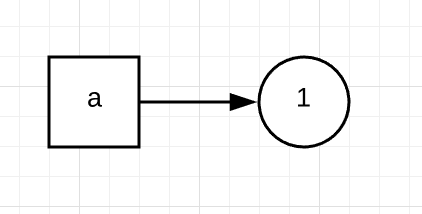
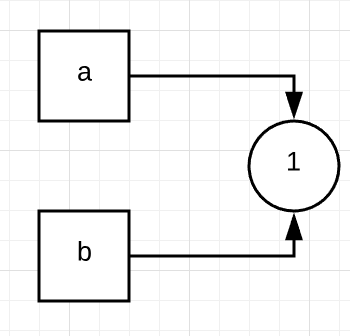

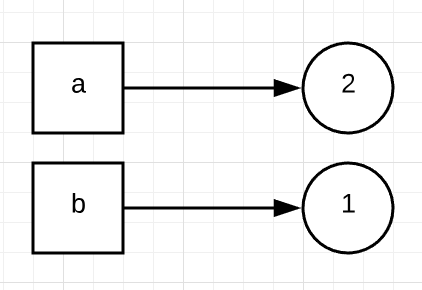


In [2]:
l1 = [1,2,3]
l2 = l1
l1.append(4)
print('l1= {}, l2={}'.format(l1,l2))

l1= [1, 2, 3, 4], l2=[1, 2, 3, 4]


上面例子：我们首先让列表 l1 和 l2 同时指向了 [1, 2, 3] 这个对象。
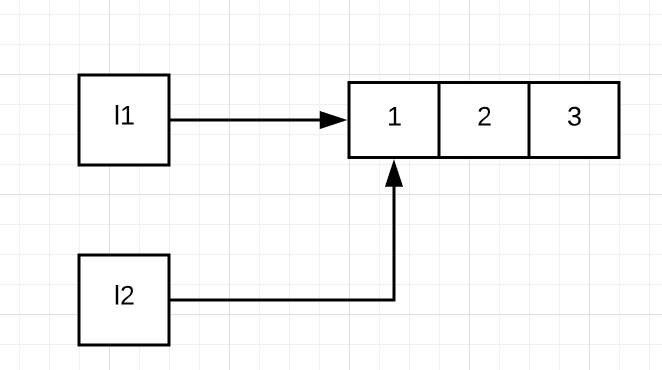


由于列表是可变的，所以 l1.append(4) 不会创建新的列表，只是在原列表的末尾插入了元素 4，变成 [1, 2, 3, 4]。由于 l1 和 l2 同时指向这个列表，所以列表的变化会同时反映在 l1 和 l2 这两个变量上，那么，l1 和 l2 的值就同时变为了 [1, 2, 3, 4]。

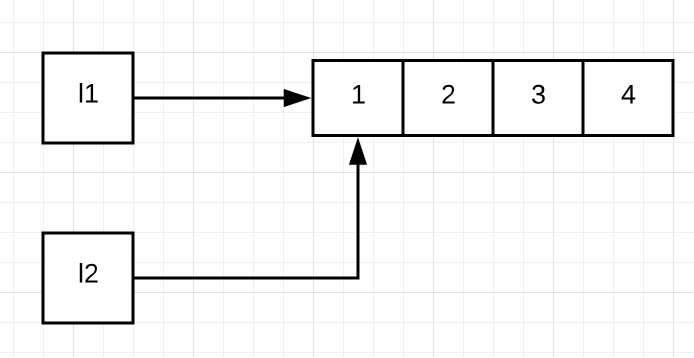


**Python 的变量本质：**

变量是“标签”，对象才是“实体”

① 变量是“标签”，对象才是数据本体

a = 1：创建对象 1，再让变量 a 指向它。

b = a：b 也指向同一个对象。

a = a + 1：创建新对象 2，让 a 指向它；b 仍指向 1。

② 可变 vs 不可变对象

不可变对象（int、str、tuple）：修改会创建新对象。

可变对象（list、dict、set）：修改会直接改变原对象，所有指向它的变量都会看到变化。

③ 删除变量不等于删除对象

del l 删除的是变量名，不是对象本身；对象是否回收取决于引用计数。


**Python 函数参数的真实机制：赋值传递**

Python 的参数传递规则：

**传递的是对象引用，但函数内部重新赋值不会影响外部变量。**

**关键区别：修改对象 vs 重新赋值**

修改对象（可变类型） → 外部变量会受影响

重新赋值（指向新对象） → 外部变量不受影响

这是理解 Python 参数传递的核心。

In [9]:
#1、不可变对象作为参数
'''
a和b 最初指向同一个对象 1
b=2 让 b 指向新对象 2
a 不变
'''
def my_func1(b):
  b = 2
a = 1
my_func1(a)

print('func1 不改变 a={}'.format(a))

def my_func2(b):
  b = 2
  return b

a = my_func2(a)

print('func2 改变 a={}'.format(a))


#2、可变对象作为参数（会被修改）
'''
append 修改原列表
所有指向该列表的变量都会看到变化
'''
def my_func3(l2):
  l2.append(4)

l1 = [1,2,3]
my_func3(l1)

print('func3 改变 l1={}'.format(l1))

#3、看似修改但实际创建新对象（不会影响外部）
'''
l4 + [4] 创建新列表
函数内部的 l4指向新对象
外部列表不变
'''
def my_func4(l4):
  l4 = l4 + [4]

l3 = [1,2,3]
my_func4(l3)

print('func4 改变 l3={}'.format(l3))

func1 不改变 a=1
func2 改变 a=2
func3 改变 l1=[1, 2, 3, 4]
func4 改变 l3=[1, 2, 3]


In [13]:
#列表是可变对象，每创建一个列表，都会重新分配内存 l1和l2并不是同一个对象
l1 = [1,2,3]
l2 = [1,2,3]
l3 = l2

l2.append(4)

print(l1)
print(l2)
print(l3)

#后面的 d 相当于指向新的对象，但是不改变原有的字典对象
def func(d):
  d['a'] = 10
  d['b'] = 20
  d = {'a':1,'b':2}

d ={}
func(d)
print(d)

[1, 2, 3]
[1, 2, 3, 4]
[1, 2, 3, 4]
{'a': 10, 'b': 20}
